In [1]:
import os
import copy
from collections import defaultdict
import itertools

from tqdm import tqdm

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.insert(1, '../../.')
from Kang_utils import all_data, pca_mod

sys.path.insert(1, '../../../.') 
from notebook_utils import get_split

sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io

from scLEMBAS.metrics import distances 

In [2]:
seed = 888
data_path = '/home/hmbaghda/orcd/pool/scLEMBAS/analysis'
author = 'Kang'

n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(1)
os.environ["MKL_NUM_THREADS"] = str(1)
os.environ["OPENBLAS_NUM_THREADS"] = str(1)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(1)
os.environ["NUMEXPR_NUM_THREADS"] = str(1)


In [3]:
(sn_ppis, tf_adata, adata, expr, source_label, target_label, weight_label, 
 stimulation_label, inhibition_label, cat_col, pert_col) = all_data

merged_adatas = io.read_pickled_object(
    os.path.join(data_path, 'processed', '{}_scLEMBAS_model_predictions.pickle'.format(author))
)
for v in  merged_adatas.values():
    v.obs_names_make_unique()


# format for input to emd loss function
cspm = {}
for fold in range(5):
    split = get_split(fold, author)
    test_conds = split['test_conds']
    for test_cond in test_conds:
        cspm[test_cond] = copy.deepcopy(pca_mod)
        
    

In [4]:
def load_test_tfadata(fold, key):
    key_ = '{}_{}'.format(key, fold)
    tf_adata_merged = merged_adatas[key_].copy()
        
    split = get_split(fold, author)
    test_conds = split['test_conds']

    test_cond_mask = tf_adata_merged.obs.condition.isin(test_conds)
    tf_adata_test = tf_adata_merged[test_cond_mask,:].copy()
    assert 'predicted_ctrl' not in tf_adata_test.obs.batch, 'Unexpected training predictions present'
    
    predicted_mask = (tf_adata_test.obs.batch == 'predicted')
    tf_adata_predicted = tf_adata_test[predicted_mask, :].copy()    
    tf_adata_actual = tf_adata_test[~predicted_mask, :].copy()
    assert len(np.where(tf_adata.obs.condition.isin(test_conds))[0]) == tf_adata_actual.shape[0], 'Incorrect subsetting of actual data'

    return tf_adata_actual, tf_adata_predicted



In [5]:
remove_types = [
    'none',
    ['adj', 'categorical_bias'],
    ['adj', 'global_bias'],
    'total_bias', 
    'adj',
    'categorical_bias',
    'global_bias'
]
remove_types = [rt if type(rt) != list else '^'.join(rt) for rt in remove_types]

ablated_components = {
    'none': 'None', 
    'global_bias': 'Global Bias', 
    'adj^global_bias': 'Adj + Global Bias', 
    'total_bias': 'Total Bias',
    'adj^categorical_bias': 'Adj + Categorical Bias', 
    'adj': 'Adjaceny Matrix Only', 
    'categorical_bias': 'Categorical Bias Only', 
                       }
remaining_components = {'none': 'Full Model', 
                        'global_bias': 'Adj + Categorical Bias', 
                        'adj^global_bias': 'Categorical Bias Only',
                        'total_bias': 'Adjaceny Matrix Only',
                       'adj^categorical_bias': 'Global Bias Only', 
                       'adj': 'Total Bias', 
                       'categorical_bias': 'Adj + Global Bias', 
                       }

ar_c = {}
for k,v  in ablated_components.items():
    ar_c[k] =  '{}\n({})'.format(ablated_components[k], remaining_components[k])
    
    
iterables = itertools.product(range(5), remove_types)


In [6]:
loss_dict = defaultdict(list)

for (fold, key) in tqdm(iterables):
    tf_adata_actual, tf_adata_predicted = load_test_tfadata(fold, key)
    
    for latent_models in [None, cspm]:
        emd_loss = distances.get_EMD_loss(
            tf_adata_actual, tf_adata_predicted, 
            groupby_col = 'condition', # per test condition
            latent_models = latent_models, 
                    )['Mean EMD Loss']


        loss_dict['Mean EMD Loss'].append(emd_loss)
        loss_dict['Space'].append('Full Feature Space' if latent_models is None else 'PCA Space')
        loss_dict['Fold'].append(fold + 1)
        loss_dict['Model Components'].append(key)

emd_loss = pd.DataFrame(loss_dict)
baseline = (
    emd_loss[emd_loss["Model Components"] == 'none']
    .set_index(["Space", "Fold"])["Mean EMD Loss"]
)

emd_loss["Normalized Mean EMD Loss"] = (
    emd_loss["Mean EMD Loss"]/ emd_loss.set_index(["Space", "Fold"]).index.map(baseline)
)

emd_loss.to_csv(os.path.join(data_path, 'processed', '{}_emd_loss_per_component.csv'.format(author)))


In [20]:
emd_loss = pd.read_csv(os.path.join(data_path, 'processed', '{}_emd_loss_per_component.csv'.format(author)), index_col = 0)

emd_loss['Model Components'] = pd.Categorical(
    emd_loss['Model Components'].map(ar_c), 
    ordered = True, 
    categories = list(ar_c.values())
)


In [8]:
sns.set_context(
    "paper",
    rc={
        "axes.labelsize": 14,
        "axes.titlesize": 16,
        "legend.fontsize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
    }
)

In [11]:
def component_dist_viz(
    space, 
    fig_name = None, 
    show_fig = True
):

    fig, ax = plt.subplots(figsize = (5, 5), constrained_layout = True)

    viz_df = emd_loss[emd_loss.Space == space].copy()
    viz_df['Model Components'] = viz_df['Model Components'][~viz_df['Model Components'].isin([ar_c['none']])].cat.remove_unused_categories()
    viz_df = viz_df[viz_df['Model Components'].notna()].copy()


    sns.violinplot(data = viz_df, x = 'Model Components', y = 'Normalized Mean EMD Loss', ax = ax)
    ax.tick_params(axis="x", rotation=45)
    for label in ax.get_xticklabels():
        label.set_ha("right")
    ax.set_title(space)
    ax.set_xlabel('Ablated Model Component(s)')
    
    if fig_name is not None:
        dirpath  = os.path.dirname(fig_name)
        basename = os.path.basename(fig_name)
        stem, _  = os.path.splitext(basename)
        out_base = os.path.join(dirpath, stem)
        
        plt.savefig(
            "{}.png".format(out_base),
            dpi=1200,
            bbox_inches="tight",
            transparent=True,
        )

        plt.savefig(
            "{}.svg".format(out_base),
            format="svg",
            bbox_inches="tight",
        )
        
    if show_fig:
        plt.show()
    ;

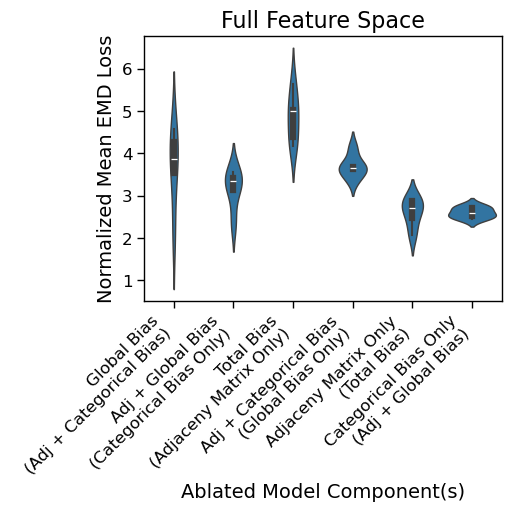

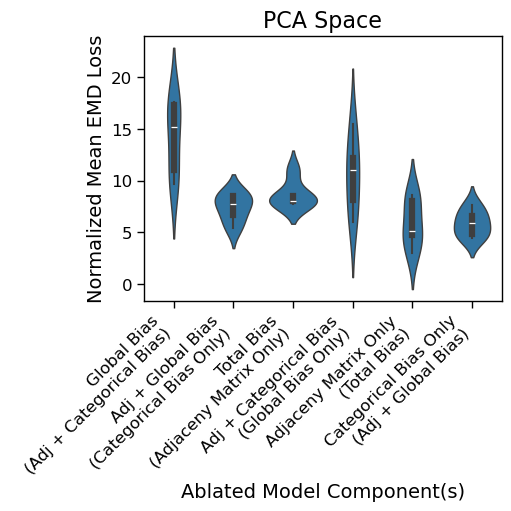

In [12]:
for space in ['Full Feature Space', 'PCA Space']:
    component_dist_viz(space = space, 
                      fig_name = None, # '{}_{}_per_component_loss_distributions'.format(author, space), 
                      show_fig = True)
    

In [25]:
# %% Visualization
def component_dist_viz(fig_name=None, show_fig=True):
    fig, ax = plt.subplots(figsize=(5, 5), constrained_layout=True)

    # Drop the unablated full model ('none') from the violins
    viz_df = emd_loss[emd_loss.Space == 'Full Feature Space'].copy()
#     viz_df = emd_loss[emd_loss.Space == 'PCA Space'].copy()
    viz_df['Model Components'] = (
        viz_df['Model Components'][~viz_df['Model Components'].isin([ar_c['none']])]
        .cat.remove_unused_categories()
    )
    viz_df = viz_df[viz_df['Model Components'].notna()].copy()

    sns.violinplot(data=viz_df, x='Model Components', y='Normalized Mean EMD Loss', ax=ax)

    ax.axhline(y=0, color="black", label="Perfect Prediction")
    ax.axhline(y=1, color="red", linestyle="--", label="Normalized Full Model Loss")
    ax.legend(loc="upper center", bbox_to_anchor=(0.55, 0.995))

    ax.tick_params(axis="x", rotation=45)
    for label in ax.get_xticklabels():
        label.set_ha("right")
    ax.set_xlabel('Ablated Model Component(s)')
    
    fig.suptitle('Kang Dataset', fontsize = 16, fontweight = 'bold')

    if fig_name is not None:
        dirpath = os.path.dirname(fig_name)
        basename = os.path.basename(fig_name)
        stem, _ = os.path.splitext(basename)
        out_base = os.path.join(dirpath, stem)
        print("{}.png".format(out_base))
        plt.savefig("{}.png".format(out_base), dpi=600, bbox_inches="tight", transparent=True)
        
    

    if show_fig:
        plt.show()



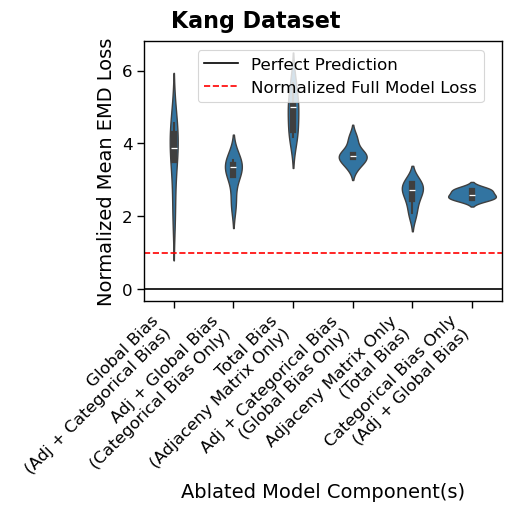

In [27]:
with sns.plotting_context(
    "paper",
    rc={
        "axes.labelsize": 14,
        "axes.titlesize": 16,
        "legend.fontsize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
    }
):

    component_dist_viz(
        fig_name=None, #os.path.join(data_path, 'figures','{}_per_component_loss_distributions_figure.png'.format(author)),
        show_fig=True,
    )

In [30]:
import itertools
from matplotlib.patches import Rectangle

remove_types = [
    'none',
    ['adj', 'categorical_bias'],
    ['adj', 'global_bias'],
    'total_bias',
    'adj',
    'categorical_bias',
    'global_bias'
]
remove_types = [rt if type(rt) != list else '^'.join(rt) for rt in remove_types]

ablated_components = {
    'none': 'None',
    'global_bias': 'Global Bias',
    'adj^global_bias': 'Adj + Global Bias',
    'total_bias': 'Total Bias',
    'adj^categorical_bias': 'Adj + Categorical Bias',
    'adj': 'Adjaceny Matrix Only',
    'categorical_bias': 'Categorical Bias Only',
}
remaining_components = {
    'none': 'Full Model',
    'global_bias': 'Adj + Categorical Bias',
    'adj^global_bias': 'Categorical Bias Only',
    'total_bias': 'Adjaceny Matrix Only',
    'adj^categorical_bias': 'Global Bias Only',
    'adj': 'Total Bias',
    'categorical_bias': 'Adj + Global Bias',
}

ar_c = {}
for k, v in ablated_components.items():
    ar_c[k] = '{}\n({})'.format(ablated_components[k], remaining_components[k])

# retained components per remove_type (A = adjacency, G = global bias, C = categorical bias)
retained_letters = {
    'none':                 {'A', 'G', 'C'},
    'global_bias':          {'A', 'C'},
    'adj^global_bias':      {'C'},
    'total_bias':           {'A'},
    'adj^categorical_bias': {'G'},
    'adj':                  {'G', 'C'},
    'categorical_bias':     {'A', 'G'},
}
label_to_key = {v: k for k, v in ar_c.items()}

iterables = itertools.product(range(5), remove_types)


# %% Visualization
def _retained_runs(key, letter_order):
    """Contiguous runs of retained letters (for merged boxes)."""
    runs, run = [], []
    for letter in letter_order:
        if letter in retained_letters[key]:
            run.append(letter)
        elif run:
            runs.append(run)
            run = []
    if run:
        runs.append(run)
    return runs

def _ablated_runs(key, letter_order):
    """Contiguous runs of ablated letters (for merged boxes)."""
    runs, run = [], []
    for letter in letter_order:
        if letter not in retained_letters[key]:   # <-- was: in
            run.append(letter)
        elif run:
            runs.append(run)
            run = []
    if run:
        runs.append(run)
    return runs


def component_dist_viz(fig_name=None, show_fig=True, horizontal=True):
    """horizontal=True: violins horizontal, component ticks on y-axis.
    horizontal=False: violins vertical, component ticks on x-axis (letters stacked)."""
    fig, ax = plt.subplots(figsize=(5, 5), constrained_layout=True)

    # Drop the unablated full model ('none') from the violins
    viz_df = emd_loss[emd_loss.Space == 'Full Feature Space'].copy()
    viz_df['Model Components'] = (
        viz_df['Model Components'][~viz_df['Model Components'].isin([ar_c['none']])]
        .cat.remove_unused_categories()
    )
    viz_df = viz_df[viz_df['Model Components'].notna()].copy()

    letter_order = ['A', 'G', 'C']
    fontsize = plt.rcParams['ytick.labelsize']

    if horizontal:
        sns.violinplot(data=viz_df, y='Model Components', x='Normalized Mean EMD Loss', ax=ax)
        ax.axvline(x=0, color="black", label="Perfect Prediction")
        ax.axvline(x=1, color="red", linestyle="--", label="Normalized Full Model Loss")
        ax.legend(loc="upper right")

        tick_positions = ax.get_yticks()
        tick_labels = [t.get_text() for t in ax.get_yticklabels()]
        ax.set_yticklabels([''] * len(tick_labels))

        # wider spacing between letters; wider + slightly shorter boxes
        letter_off = {'A': -0.19, 'G': -0.13, 'C': -0.07}  # axes-fraction x offsets
        box_pad = 0.026    # padding along letter direction (axes fraction) — wider
        box_half = 0.21    # half-extent along category direction (data coords) — shorter
        tr = ax.get_yaxis_transform()  # (x: axes fraction, y: data)

        for pos, lbl in zip(tick_positions, tick_labels):
            key = label_to_key[lbl]
            for letter in letter_order:
                ax.text(letter_off[letter], pos, letter, transform=tr,
                        ha='center', va='center', fontsize=fontsize, clip_on=False)
            for run in _ablated_runs(key, letter_order):
                x0 = letter_off[run[0]] - box_pad
                x1 = letter_off[run[-1]] + box_pad
                ax.add_patch(Rectangle(
                    (x0, pos - box_half), x1 - x0, 2 * box_half,
                    transform=tr, facecolor='none', edgecolor='black',
                    linewidth=1.2, clip_on=False))

        ax.set_ylabel('Model Component Ablation', labelpad=65)

    else:
        sns.violinplot(data=viz_df, x='Model Components', y='Normalized Mean EMD Loss', ax=ax)
        ax.axhline(y=0, color="black", label="Perfect Prediction")
        ax.axhline(y=1, color="red", linestyle="--", label="Normalized Full Model Loss")
        ax.legend(loc="lower center", bbox_to_anchor=(0.5, 0.1))

        tick_positions = ax.get_xticks()
        tick_labels = [t.get_text() for t in ax.get_xticklabels()]
        ax.set_xticklabels([''] * len(tick_labels))

#         # wider spacing between letters; narrower + slightly taller boxes
#         letter_off = {'A': -0.06, 'G': -0.115, 'C': -0.17}  # axes-fraction y offsets (top to bottom)
#         box_pad = 0.028    # padding along letter direction (axes fraction) — taller
#         box_half = 0.32    # half-width along category direction (data coords) — narrower
        
        
        letter_off = {'A': -0.062, 'G': -0.1252, 'C': -0.192}  # spacing 0.055 → 0.065
        box_pad = 0.032
        box_half = 0.21    # narrower: 0.32 → 0.27
        
        tr = ax.get_xaxis_transform()  # (x: data, y: axes fraction)


        for pos, lbl in zip(tick_positions, tick_labels):
            key = label_to_key[lbl]
            for letter in letter_order:
                ax.text(pos, letter_off[letter], letter, transform=tr,
                        ha='center', va='center', fontsize=fontsize, clip_on=False)
            for run in _ablated_runs(key, letter_order):
                y_top = letter_off[run[0]] + box_pad
                y_bot = letter_off[run[-1]] - box_pad
                ax.add_patch(Rectangle(
                    (pos - box_half, y_bot), 2 * box_half, y_top - y_bot,
                    transform=tr, facecolor='none', edgecolor='black',
                    linewidth=1.2, clip_on=False))

        ax.set_xlabel('Model Component Ablation', labelpad=65)

    fig.suptitle('{} Dataset'.format(author), fontsize=16, fontweight='bold')

    if fig_name is not None:
        dirpath = os.path.dirname(fig_name)
        basename = os.path.basename(fig_name)
        stem, _ = os.path.splitext(basename)
        out_base = os.path.join(dirpath, stem)
        print("{}.png".format(out_base))
        plt.savefig("{}.png".format(out_base), dpi=600, bbox_inches="tight", transparent=True)

    if show_fig:
        plt.show()




/tmp/ipykernel_3916456/3452352907.py:136: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] * len(tick_labels))


/home/hmbaghda/orcd/pool/scLEMBAS/analysis/figures/Kang_per_component_loss_distributions_figure.png


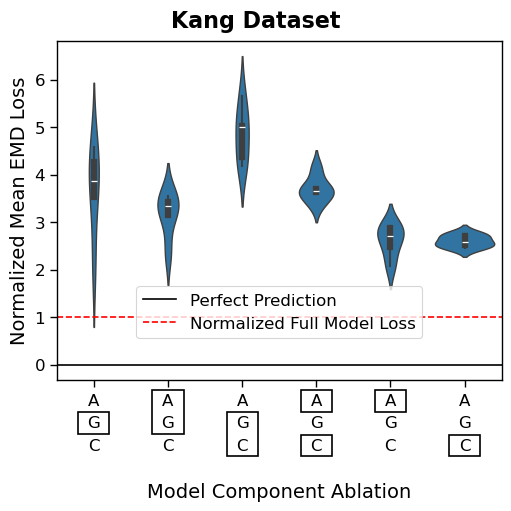

In [31]:
with sns.plotting_context(
    "paper",
    rc={
        "axes.labelsize": 14,
        "axes.titlesize": 16,
        "legend.fontsize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
    }
):
    component_dist_viz(
        fig_name=os.path.join(data_path, 'figures', '{}_per_component_loss_distributions_figure.png'.format(author)),
        show_fig=True,
        horizontal=False,  # False = original vertical orientation
    )

/tmp/ipykernel_4131033/3955441633.py:9: PendingDeprecationWarning: The set_constrained_layout_pads function will be deprecated in a future version. Use figure.get_layout_engine().set() instead.
  fig.set_constrained_layout_pads(h_pad=0.15, w_pad=0.05, hspace=0.15)


''

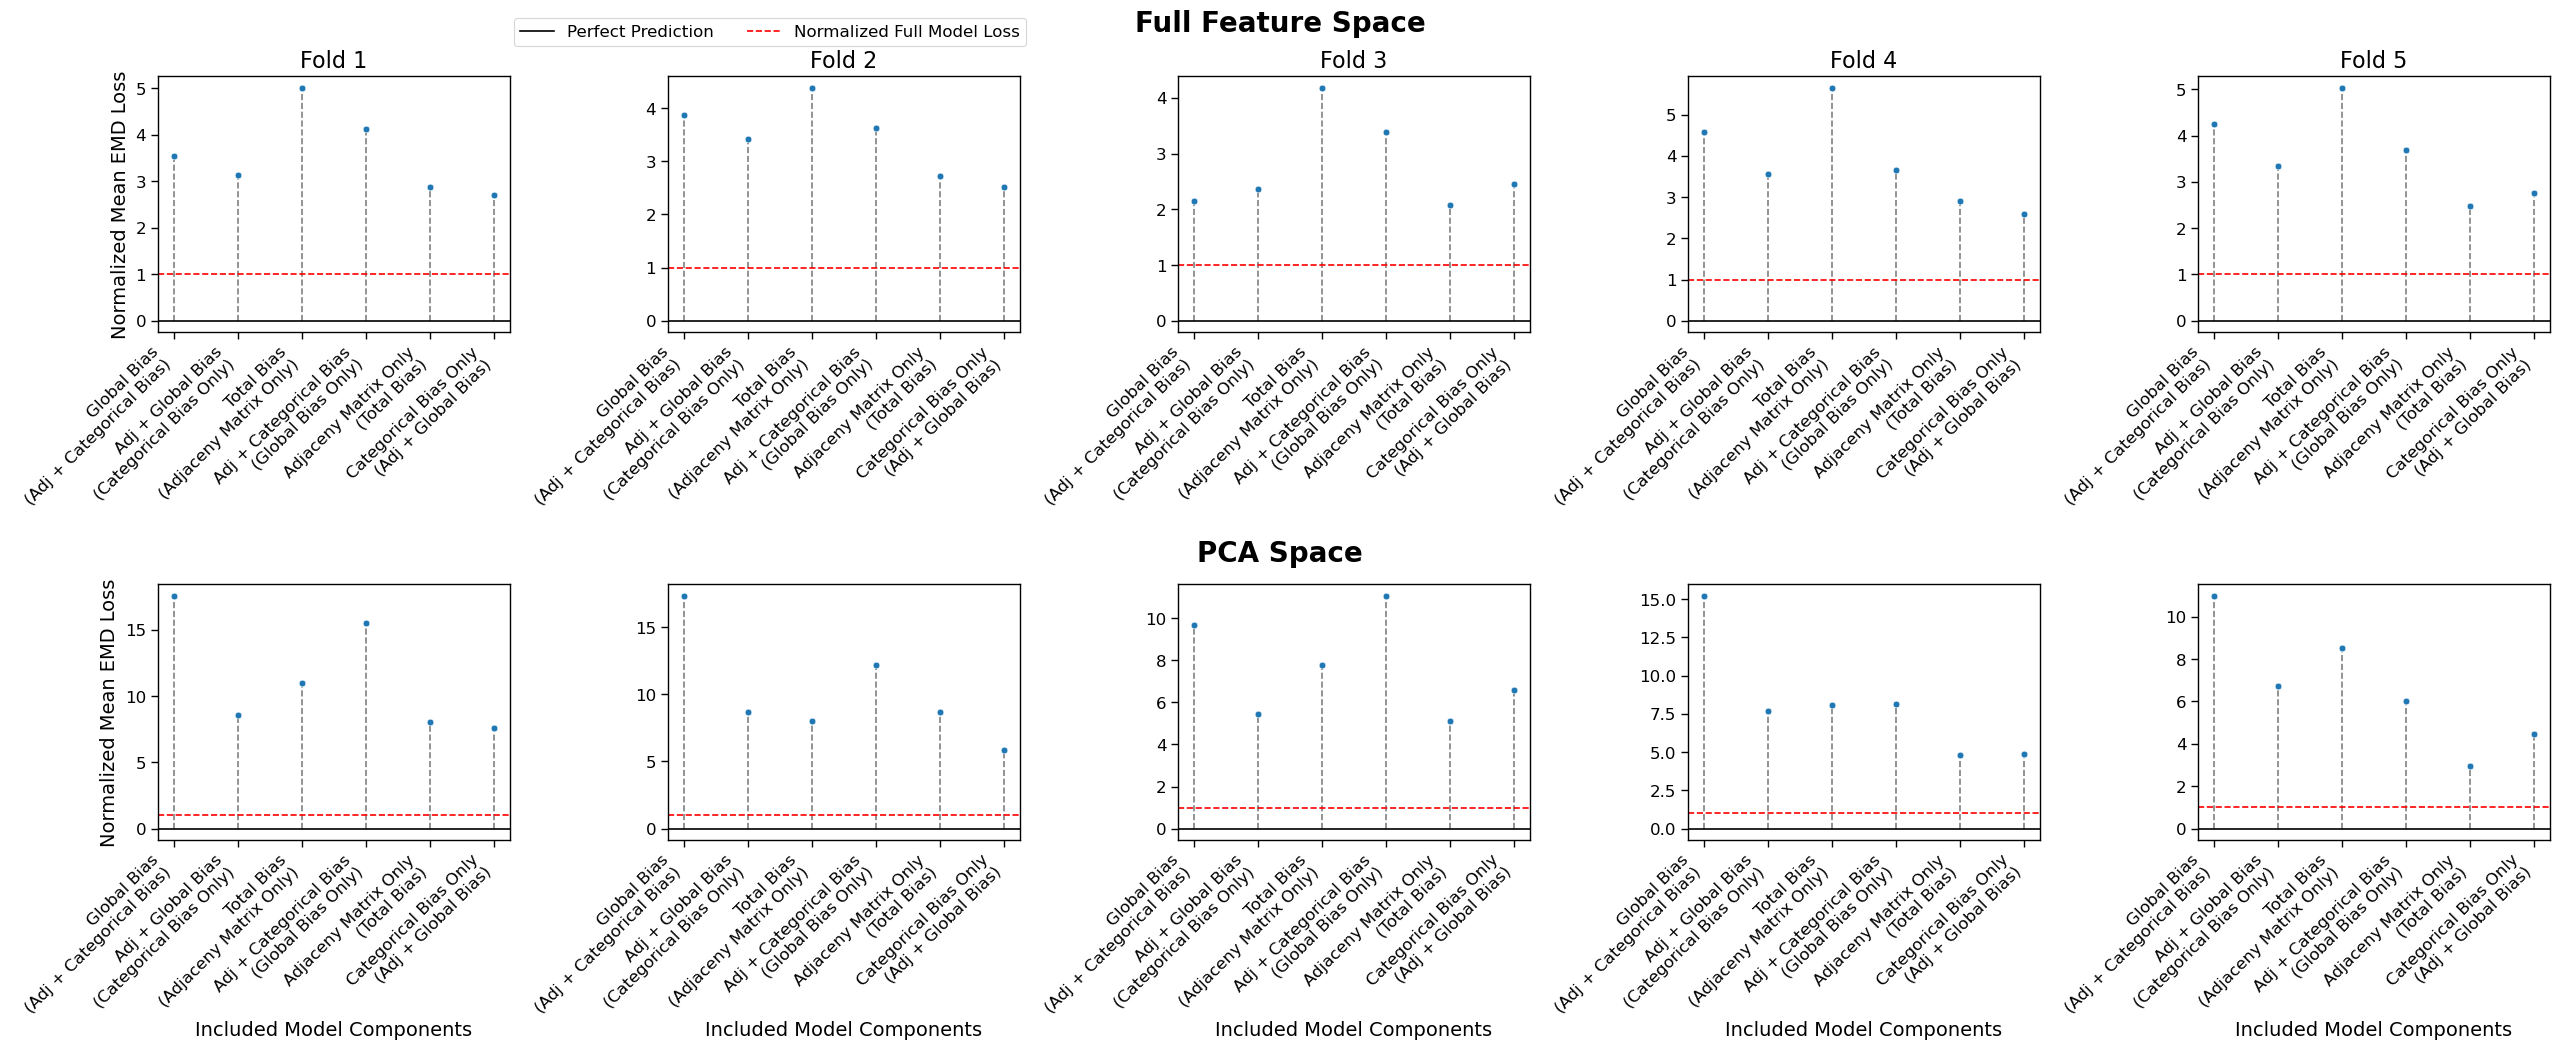

In [27]:
ncols = 5
nrows = 2
fig, ax = plt.subplots(
    ncols=ncols,
    nrows=nrows,
    figsize=(5.1*ncols, 5.1*nrows),
    constrained_layout=True
)
fig.set_constrained_layout_pads(h_pad=0.15, w_pad=0.05, hspace=0.15)

row_spaces = [
    "Full Feature Space",
    "PCA Space"
]

for i, space in enumerate(row_spaces):

    # ---- IMPORTANT: filter per row ----
    viz_df = emd_loss[emd_loss.Space == space].copy()
    viz_df = viz_df[~viz_df["Model Components"].isin([ar_c['none']])].copy()
    viz_df["Model Components"] = viz_df["Model Components"].cat.remove_unused_categories()

    for j in range(ncols):
        fold = j + 1
        viz_df_fold = viz_df[viz_df.Fold == fold]

        sns.scatterplot(
            data=viz_df_fold,
            x="Model Components",
            y="Normalized Mean EMD Loss",
            ax=ax[i, j]
        )

        ax[i, j].tick_params(axis="x", rotation=45)
        for label in ax[i, j].get_xticklabels():
            label.set_ha("right")

        ax[i, j].axhline(y=0, color="black", label="Perfect Prediction")
        ax[i, j].axhline(y=1, color="red", linestyle="--", label="Normalized Full Model Loss")

        for x, y in zip(
            viz_df_fold["Model Components"],
            viz_df_fold["Normalized Mean EMD Loss"]
        ):
            ax[i, j].vlines(x, ymin=0, ymax=y, linestyle="dashed", color="gray", zorder=0)

        ax[i, j].set_title(f"Fold {fold}")
        ax[i, j].set_xlabel("Included Model Components")

        if (i, j) == (0, 0):
            ax[i, j].legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        if j != 0:
            ax[i,j].set_ylabel('')
        if i != 1:
            ax[i,j].set_xlabel('')
        if i != 0:
            ax[i,j].set_title('')
            
            


# ---- shared legend (unchanged) ----
leg = ax[0, 0].get_legend()
handles = leg.legend_handles
labels = [t.get_text() for t in leg.get_texts()]

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.3, 1.025)
)
ax[0, 0].legend_.remove()

# ---- row-level "suptitles" ----
fig.text(0.5, 1.025, row_spaces[0], ha="center", va="top", fontsize=20, fontweight="bold")
fig.text(0.5, 0.505,  row_spaces[1], ha="center", va="top", fontsize=20, fontweight="bold")
;

/tmp/ipykernel_3916456/2646257517.py:46: PendingDeprecationWarning: The set_constrained_layout_pads function will be deprecated in a future version. Use figure.get_layout_engine().set() instead.
  fig.set_constrained_layout_pads(h_pad=0.15, w_pad=0.05, hspace=0.15)
/tmp/ipykernel_3916456/2646257517.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] * len(tick_labels))
/tmp/ipykernel_3916456/2646257517.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] * len(tick_labels))
/tmp/ipykernel_3916456/2646257517.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] * len(tick_labels))
/tmp/ipykernel_3916456/2646257517.py:12: UserWarning: set_ticklabels() should only be use

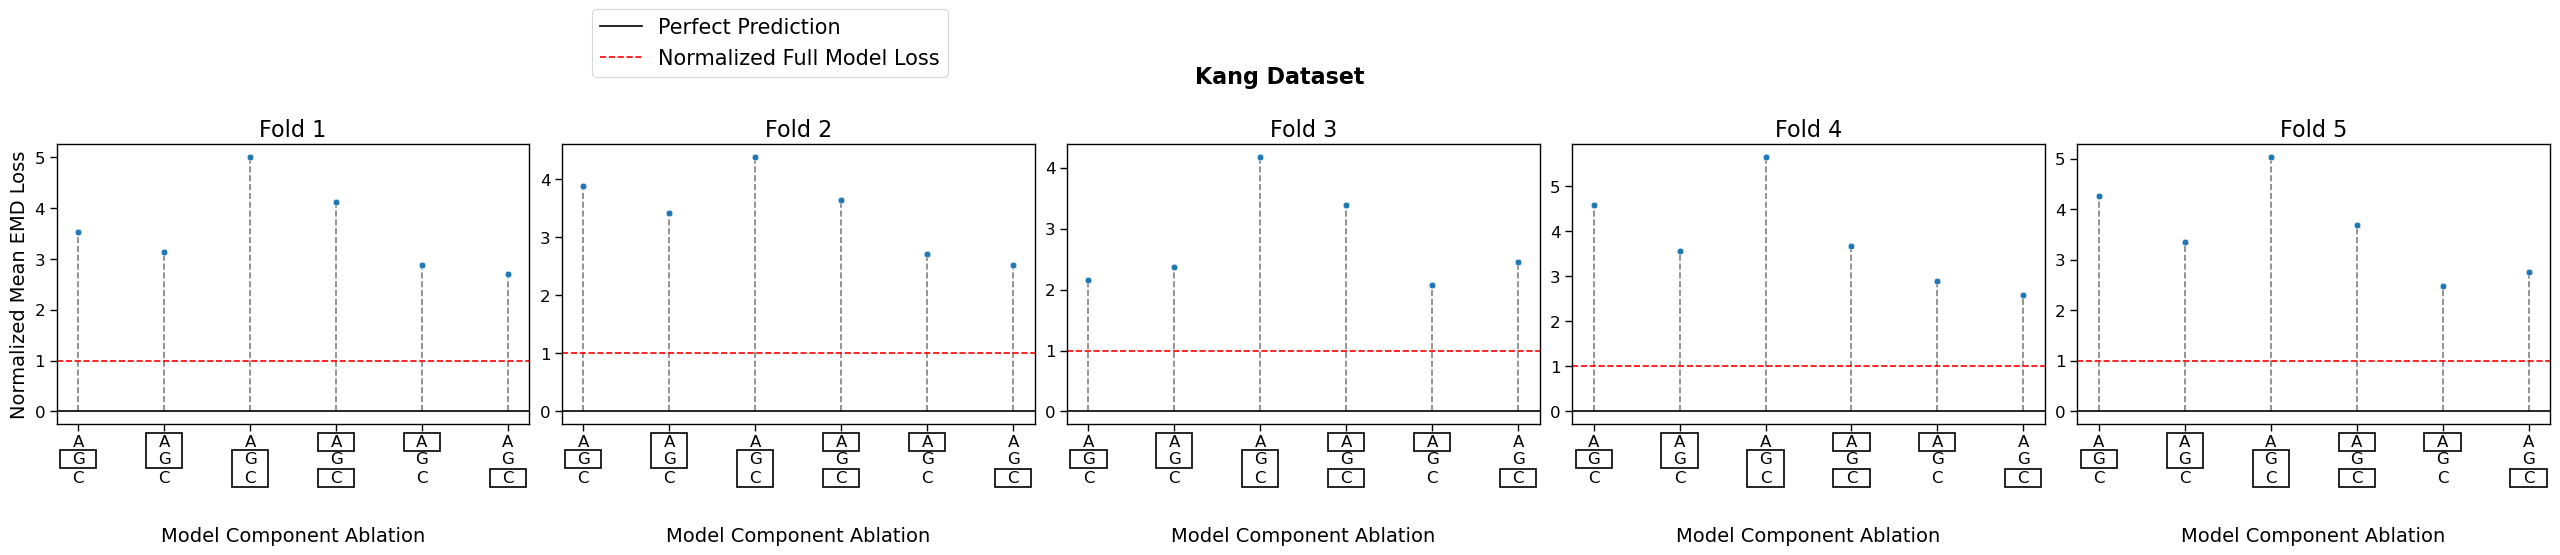

In [33]:
def _component_letter_xticks(ax, letter_order=('A', 'G', 'C'),
                             letter_off=None, box_pad=0.032, box_half=0.21,
                             fontsize=None):
    """Replace x tick labels with stacked A/G/C letters; box the ablated runs."""
    if letter_off is None:
        letter_off = {'A': -0.062, 'G': -0.1252, 'C': -0.192}
    if fontsize is None:
        fontsize = plt.rcParams['xtick.labelsize']

    tick_positions = ax.get_xticks()
    tick_labels = [t.get_text() for t in ax.get_xticklabels()]
    ax.set_xticklabels([''] * len(tick_labels))
    tr = ax.get_xaxis_transform()  # (x: data, y: axes fraction)

    for pos, lbl in zip(tick_positions, tick_labels):
        key = label_to_key[lbl]
        for letter in letter_order:
            ax.text(pos, letter_off[letter], letter, transform=tr,
                    ha='center', va='center', fontsize=fontsize, clip_on=False)
        for run in _ablated_runs(key, letter_order):
            y_top = letter_off[run[0]] + box_pad
            y_bot = letter_off[run[-1]] - box_pad
            ax.add_patch(Rectangle(
                (pos - box_half, y_bot), 2 * box_half, y_top - y_bot,
                transform=tr, facecolor='none', edgecolor='black',
                linewidth=1.2, clip_on=False))

with sns.plotting_context(
    "paper", font_scale=1.2,
    rc={
        "axes.labelsize": 14,
        "axes.titlesize": 16,
        "legend.fontsize": 15,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
    }
):

    ncols = 5
    fig, ax = plt.subplots(
        ncols=ncols,
        nrows=1,
        figsize=(5.1*ncols, 5.1),
        constrained_layout=True
    )
    fig.set_constrained_layout_pads(h_pad=0.15, w_pad=0.05, hspace=0.15)

    space = "Full Feature Space"

    # ---- filter for the single space ----
    viz_df = emd_loss[emd_loss.Space == space].copy()
    viz_df = viz_df[~viz_df["Model Components"].isin([ar_c['none']])].copy()
    viz_df["Model Components"] = viz_df["Model Components"].cat.remove_unused_categories()

    for j in range(ncols):
        fold = j + 1
        viz_df_fold = viz_df[viz_df.Fold == fold]
        sns.scatterplot(
            data=viz_df_fold,
            x="Model Components",
            y="Normalized Mean EMD Loss",
            ax=ax[j]
        )
        ax[j].axhline(y=0, color="black", label="Perfect Prediction")
        ax[j].axhline(y=1, color="red", linestyle="--", label="Normalized Full Model Loss")
        for x, y in zip(
            viz_df_fold["Model Components"],
            viz_df_fold["Normalized Mean EMD Loss"]
        ):
            ax[j].vlines(x, ymin=0, ymax=y, linestyle="dashed", color="gray", zorder=0)

        _component_letter_xticks(ax[j])

        ax[j].set_title(f"Fold {fold}")
        ax[j].set_xlabel("Model Component Ablation", labelpad=65)
        if j == 0:
            ax[j].legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        if j != 0:
            ax[j].set_ylabel('')

    # ---- shared legend ----
    leg = ax[0].get_legend()
    handles = leg.legend_handles
    labels = [t.get_text() for t in leg.get_texts()]
    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.3, 1.1)
    )
    ax[0].legend_.remove()
    fig.suptitle('Kang Dataset', fontsize=16, fontweight='bold')
    fig.savefig(os.path.join(data_path, 'figures', '{}_individual_component_per_fold.png'.format(author)), dpi=600, bbox_inches='tight')
    
    
    